# EEEM068 - Multi-View ViT-Small + SiT-S - Part 1

**Scope:** Setup, configuration, labels, stratified split, and exploratory analysis

**Source notebook:** `EEEM068_SiT_S_Final_FIXED (2).ipynb`

**Notes**
- This notebook is a split component of the original final notebook.
- Some setup cells are intentionally repeated so each part is easier to understand in isolation.
- If you want to run the full pipeline end-to-end, use the original notebook or follow the README in sequence.

# EEEM068 — Knee MRI Classification · ViT-Small + SiT-S
**University of Surrey — Applied Machine Learning (Spring 2026)**

| Item | Detail |
|---|---|
| Model | Multi-View ViT-Small patch16/224 (shared backbone, 3 planes) |
| Pretrained weights | **SiT-S** — Sara Ahmed et al. 2021 (self-supervised ImageNet) |
| Dataset | MRNet — 1,370 knee MRI exams (Stanford University Medical Center) |
| Task | Multi-label: ACL tear · Meniscus tear · Abnormal |
| Loss | Focal BCE (γ=0.5) + Label smoothing + MixUp |

**Run order:** Execute cells top-to-bottom. Edit only the two paths in Section 1.

---


## Section 1 — Imports & Configuration

In [1]:
import os, io, gc, math, pickle, random, warnings, urllib.request
from pathlib import Path
from io import BytesIO
from collections import deque, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as T
import timm

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch : 2.11.0+cu130
timm    : 1.0.27
CUDA    : True
GPU     : NVIDIA RTX A4000
VRAM    : 16.7 GB


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — fixed for your Surrey/otter AML folder
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    # ── MAIN PROJECT PATHS ────────────────────────────────────────────────────
    AML_DIR = Path("/user/HS402/mi00806/Downloads/AML")

    ROOT    = Path("/user/HS402/mi00806/.cache/kagglehub/datasets/"
                   "cjinny/mrnet-v1/versions/1/MRNet-v1.0")
    OUT_DIR = AML_DIR / "mrnet_outputs"

    # Your real downloaded SiT-S checkpoints are inside AML/sit_zip/
    SIT_DIR = AML_DIR / "sit_zip"
    SIT_VARIANT = "ImageNet"   # options: ImageNet, Pascal, Pets, STL10
    SIT_CACHE_PATH = str(SIT_DIR / f"SiT_Small_{SIT_VARIANT}.pth")

    CHECKPOINT_PATH = str(OUT_DIR / "best_vit.pth")
    TENSORBOARD_DIR = str(OUT_DIR / "tb_logs")

    IMAGE_SIZE  = 224
    MODEL_NAME  = "vit_small_patch16_224"
    NUM_CLASSES = 3
    LABEL_NAMES = ["acl", "meniscus", "abnormal"]

    TOP_K_SLICES = 5
    N_CHANNELS   = 3

    BATCH_SIZE  = 8
    EPOCHS      = 60
    MIN_EPOCHS  = 20
    PATIENCE    = 15
    NUM_WORKERS = 4
    SEED        = 42

    HEAD_LR           = 1e-3
    BACKBONE_LR_LATE  = 1e-5
    BACKBONE_LR_EARLY = 5e-6
    WEIGHT_DECAY      = 1e-4

    UNFREEZE_PARTIAL_EP = 5
    UNFREEZE_FULL_EP    = 10
    N_BLOCKS_PARTIAL    = 6
    WARMUP_EPOCHS       = 3
    WARMUP_RESTART      = 2

    DROP_PATH_RATE = 0.1
    DROPOUT_HEAD1  = 0.3
    DROPOUT_HEAD2  = 0.15
    LABEL_SMOOTH   = 0.05
    MIXUP_ALPHA    = 0.2
    MIXUP_PROB     = 0.4
    MIXUP_START_EP = UNFREEZE_PARTIAL_EP + 1

    FOCAL_GAMMA = 0.5
    FOCAL_ALPHA = [0.82, 0.63, 0.19]

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)

assert CFG.ROOT.exists(), f"Dataset not found: {CFG.ROOT}"
assert Path(CFG.SIT_CACHE_PATH).exists(), (
    f"SiT checkpoint not found: {CFG.SIT_CACHE_PATH}\n"
    f"Your downloaded files should be in: {CFG.SIT_DIR}\n"
    "Run: ls -lh /user/HS402/mi00806/Downloads/AML/sit_zip/"
)

print("CFG loaded ✅")
print(f"  Device     : {CFG.DEVICE}")
print(f"  Dataset    : {CFG.ROOT}")
print(f"  Out dir    : {CFG.OUT_DIR}")
print(f"  SiT weights: {CFG.SIT_CACHE_PATH}")
print(f"  SiT size   : {Path(CFG.SIT_CACHE_PATH).stat().st_size/1e6:.1f} MB")


CFG loaded ✅
  Device     : cuda
  Dataset    : /user/HS402/mi00806/.cache/kagglehub/datasets/cjinny/mrnet-v1/versions/1/MRNet-v1.0
  Out dir    : /user/HS402/mi00806/Downloads/AML/mrnet_outputs
  SiT weights: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
  SiT size   : 669.7 MB


## Section 2 — SiT-S Weights: Load Local Checkpoint

This version is fixed for your current folder structure.

Your real checkpoint files are already downloaded in:

```text
/user/HS402/mi00806/Downloads/AML/sit_zip/
```

The notebook now loads:

```text
SiT_Small_ImageNet.pth
```

So it will no longer look for the missing `../sit_extracted/` folder.


In [3]:
# ── SiT-S checkpoint load from your local sit_zip folder ──────────────────────
# Your downloaded files:
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_Pascal.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_Pets.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_STL10.pth

SIT_CACHE = Path(CFG.SIT_CACHE_PATH)


def load_sit_checkpoint(path):
    """Load a local SiT checkpoint safely."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    size_mb = path.stat().st_size / 1e6
    print(f"  File: {path}")
    print(f"  Size: {size_mb:.1f} MB")

    if size_mb < 100:
        raise RuntimeError(
            f"This checkpoint is too small ({size_mb:.1f} MB).\n"
            "Use the real downloaded checkpoint in AML/sit_zip/, not data.pkl or sit_small.pth."
        )

    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    print("  ✅ torch.load: OK")
    return ckpt


def extract_sit_state_dict(ckpt, ref_keys):
    """Find and clean the state dict from the SiT checkpoint."""
    ref_keys = set(ref_keys)

    candidates = {}
    if isinstance(ckpt, dict):
        for k in ["student", "teacher", "model", "state_dict", "module", "backbone"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                candidates[k] = ckpt[k]
        if not candidates:
            candidates["<root>"] = ckpt
    else:
        raise TypeError(f"Unexpected checkpoint type: {type(ckpt)}")

    best_n, best_key, best_state = 0, None, None

    prefixes = [
        "module.backbone.",
        "module.student.backbone.",
        "student.backbone.",
        "teacher.backbone.",
        "backbone.",
        "module.",
    ]

    for key, state in candidates.items():
        cleaned = {}
        for k, v in state.items():
            new_k = k
            for prefix in prefixes:
                if new_k.startswith(prefix):
                    new_k = new_k[len(prefix):]
            cleaned[new_k] = v

        n = len(ref_keys & set(cleaned.keys()))
        print(f"  key='{key}': {n}/{len(ref_keys)} keys match timm ViT-Small")

        if n > best_n:
            best_n, best_key, best_state = n, key, cleaned

    return best_key, best_state, best_n


def check_nan(state_dict):
    """Return list of keys with NaN values."""
    nan_keys = []
    for k, v in state_dict.items():
        if torch.is_tensor(v) and torch.isnan(v.float()).any():
            nan_keys.append(k)
    return nan_keys


# ── STEP 1: Use local checkpoint ──────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Using local SiT-S checkpoint")
print("=" * 60)
print(f"✅ Using: {SIT_CACHE}")

# ── STEP 2: Load and inspect ─────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 2 — Loading and inspecting checkpoint")
print("=" * 60)

raw_ckpt = load_sit_checkpoint(SIT_CACHE)
if isinstance(raw_ckpt, dict):
    print(f"Top-level keys: {list(raw_ckpt.keys())[:20]}")
    if "epoch" in raw_ckpt:
        print(f"Saved at epoch: {raw_ckpt['epoch']}")

# ── STEP 3: Build reference model and match keys ──────────────────────────────
print()
print("=" * 60)
print("STEP 3 — Matching keys to timm ViT-Small")
print("=" * 60)

_ref = timm.create_model(CFG.MODEL_NAME, pretrained=False, num_classes=0)
ref_keys = list(_ref.state_dict().keys())
print(f"timm ViT-Small has {len(ref_keys)} parameter tensors")

best_key, best_state, n_matched = extract_sit_state_dict(raw_ckpt, ref_keys)
del _ref

print(f"\nBest match: key='{best_key}'  {n_matched}/{len(ref_keys)} keys matched")

# ── STEP 4: Check health ─────────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 4 — NaN / health check")
print("=" * 60)

if best_state is not None and n_matched > 10:
    nan_keys = check_nan(best_state)
    print(f"NaN tensors: {len(nan_keys)} / {len(best_state)}")

    if nan_keys:
        print(f"NaN keys first 5: {nan_keys[:5]}")
        SIT_WEIGHTS_OK = False
        print("⚠️ SiT weights are not healthy, notebook will fall back to timm ImageNet.")
    else:
        SIT_WEIGHTS_OK = True
        print("✅ SiT checkpoint is healthy and ready to load")
else:
    SIT_WEIGHTS_OK = False
    print(f"⚠️ Only {n_matched} keys matched — notebook will fall back to timm ImageNet.")

print(f"\nSIT_WEIGHTS_OK = {SIT_WEIGHTS_OK}")


STEP 1 — Using local SiT-S checkpoint
✅ Using: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth

STEP 2 — Loading and inspecting checkpoint
  File: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
  Size: 669.7 MB
  ✅ torch.load: OK
Top-level keys: ['student', 'teacher', 'optimizer', 'epoch', 'args', 'fp16_scaler']
Saved at epoch: 715

STEP 3 — Matching keys to timm ViT-Small
timm ViT-Small has 150 parameter tensors
  key='student': 150/150 keys match timm ViT-Small
  key='teacher': 150/150 keys match timm ViT-Small

Best match: key='student'  150/150 keys matched

STEP 4 — NaN / health check
NaN tensors: 0 / 177
✅ SiT checkpoint is healthy and ready to load

SIT_WEIGHTS_OK = True


## Section 4 — Dataset Labels & Stratified Split

MRNet provides three CSV files (one per condition) for the train split.
Labels: ACL tear, Meniscus tear, Abnormal (multi-label — not mutually exclusive).
We perform a **stratified 85/15 split** on the `abnormal` label.


In [5]:
def load_labels(root, split):
    """Load and merge ACL / Abnormal / Meniscus CSVs into one DataFrame."""
    acl      = pd.read_csv(root / f"{split}-acl.csv",
                           header=None, names=["id", "acl"])
    abnormal = pd.read_csv(root / f"{split}-abnormal.csv",
                           header=None, names=["id", "abnormal"])
    meniscus = pd.read_csv(root / f"{split}-meniscus.csv",
                           header=None, names=["id", "meniscus"])
    df = acl.merge(abnormal, on="id").merge(meniscus, on="id")
    df["id"] = df["id"].astype(str).str.zfill(4)
    for plane in ["sagittal", "coronal", "axial"]:
        df[f"{plane}_path"] = df["id"].apply(
            lambda x, p=plane: str(root / "train" / p / f"{x}.npy"))
    df["target"] = df.apply(
        lambda r: [float(r["acl"]),
                   float(r["meniscus"]),
                   float(r["abnormal"])], axis=1)
    return df


all_df = load_labels(CFG.ROOT, "train")
train_df, valid_df = train_test_split(
    all_df, test_size=0.15, random_state=CFG.SEED,
    stratify=all_df["abnormal"].astype(int)
)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(f"Train : {len(train_df)} scans")
print(f"Valid : {len(valid_df)} scans  (15% stratified split)")
print()
print("Label distribution:")
for lbl in CFG.LABEL_NAMES:
    tr_n = int(train_df[lbl].sum())
    va_n = int(valid_df[lbl].sum())
    print(f"  {lbl:>10}:  "
          f"train {tr_n:>3} pos ({100*tr_n/len(train_df):.1f}%)  "
          f"| valid {va_n:>3} pos ({100*va_n/len(valid_df):.1f}%)")


Train : 960 scans
Valid : 170 scans  (15% stratified split)

Label distribution:
         acl:  train 185 pos (19.3%)  | valid  23 pos (13.5%)
    meniscus:  train 328 pos (34.2%)  | valid  69 pos (40.6%)
    abnormal:  train 776 pos (80.8%)  | valid 137 pos (80.6%)


## Section 5 — Exploratory Data Analysis

1. **Label distribution** — positive vs negative per condition
2. **Co-occurrence heatmap** — how often conditions appear together
3. **Sample slices** — 5 slices per plane, red = variance-selected


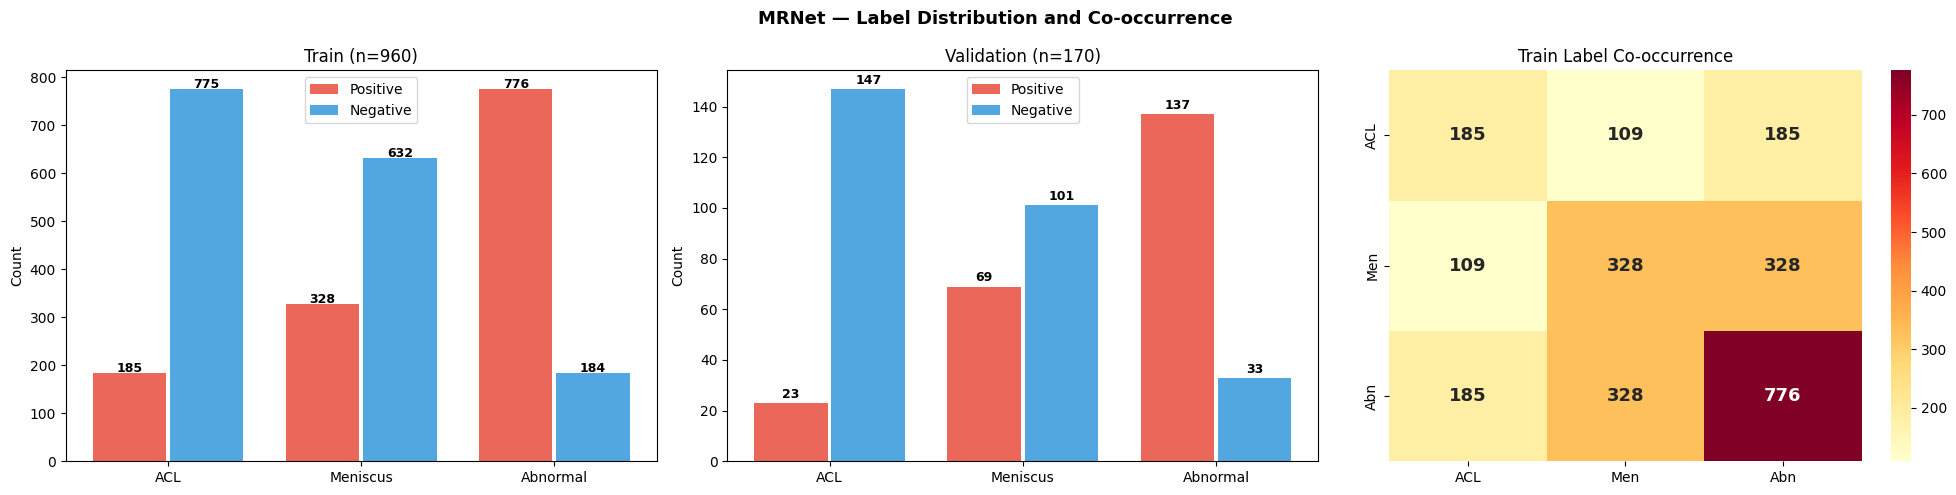

In [6]:
# Plot 1: Label distribution + co-occurrence
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("MRNet — Label Distribution and Co-occurrence",
             fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes[:2], [("Train", train_df), ("Validation", valid_df)]):
    counts = df[CFG.LABEL_NAMES].sum()
    neg    = len(df) - counts
    x = np.arange(3)
    bp = ax.bar(x-.2, counts, .38, label="Positive", color="#E74C3C", alpha=0.85)
    bn = ax.bar(x+.2, neg,    .38, label="Negative", color="#3498DB", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(["ACL","Meniscus","Abnormal"])
    ax.set_title(f"{name} (n={len(df)})"); ax.set_ylabel("Count"); ax.legend()
    for bar in list(bp)+list(bn):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(int(bar.get_height())), ha="center", fontsize=9, fontweight="bold")

co = train_df[CFG.LABEL_NAMES].T.dot(train_df[CFG.LABEL_NAMES])
sns.heatmap(co, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[2],
            xticklabels=["ACL","Men","Abn"], yticklabels=["ACL","Men","Abn"],
            annot_kws={"size":13,"weight":"bold"})
axes[2].set_title("Train Label Co-occurrence")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR/"eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


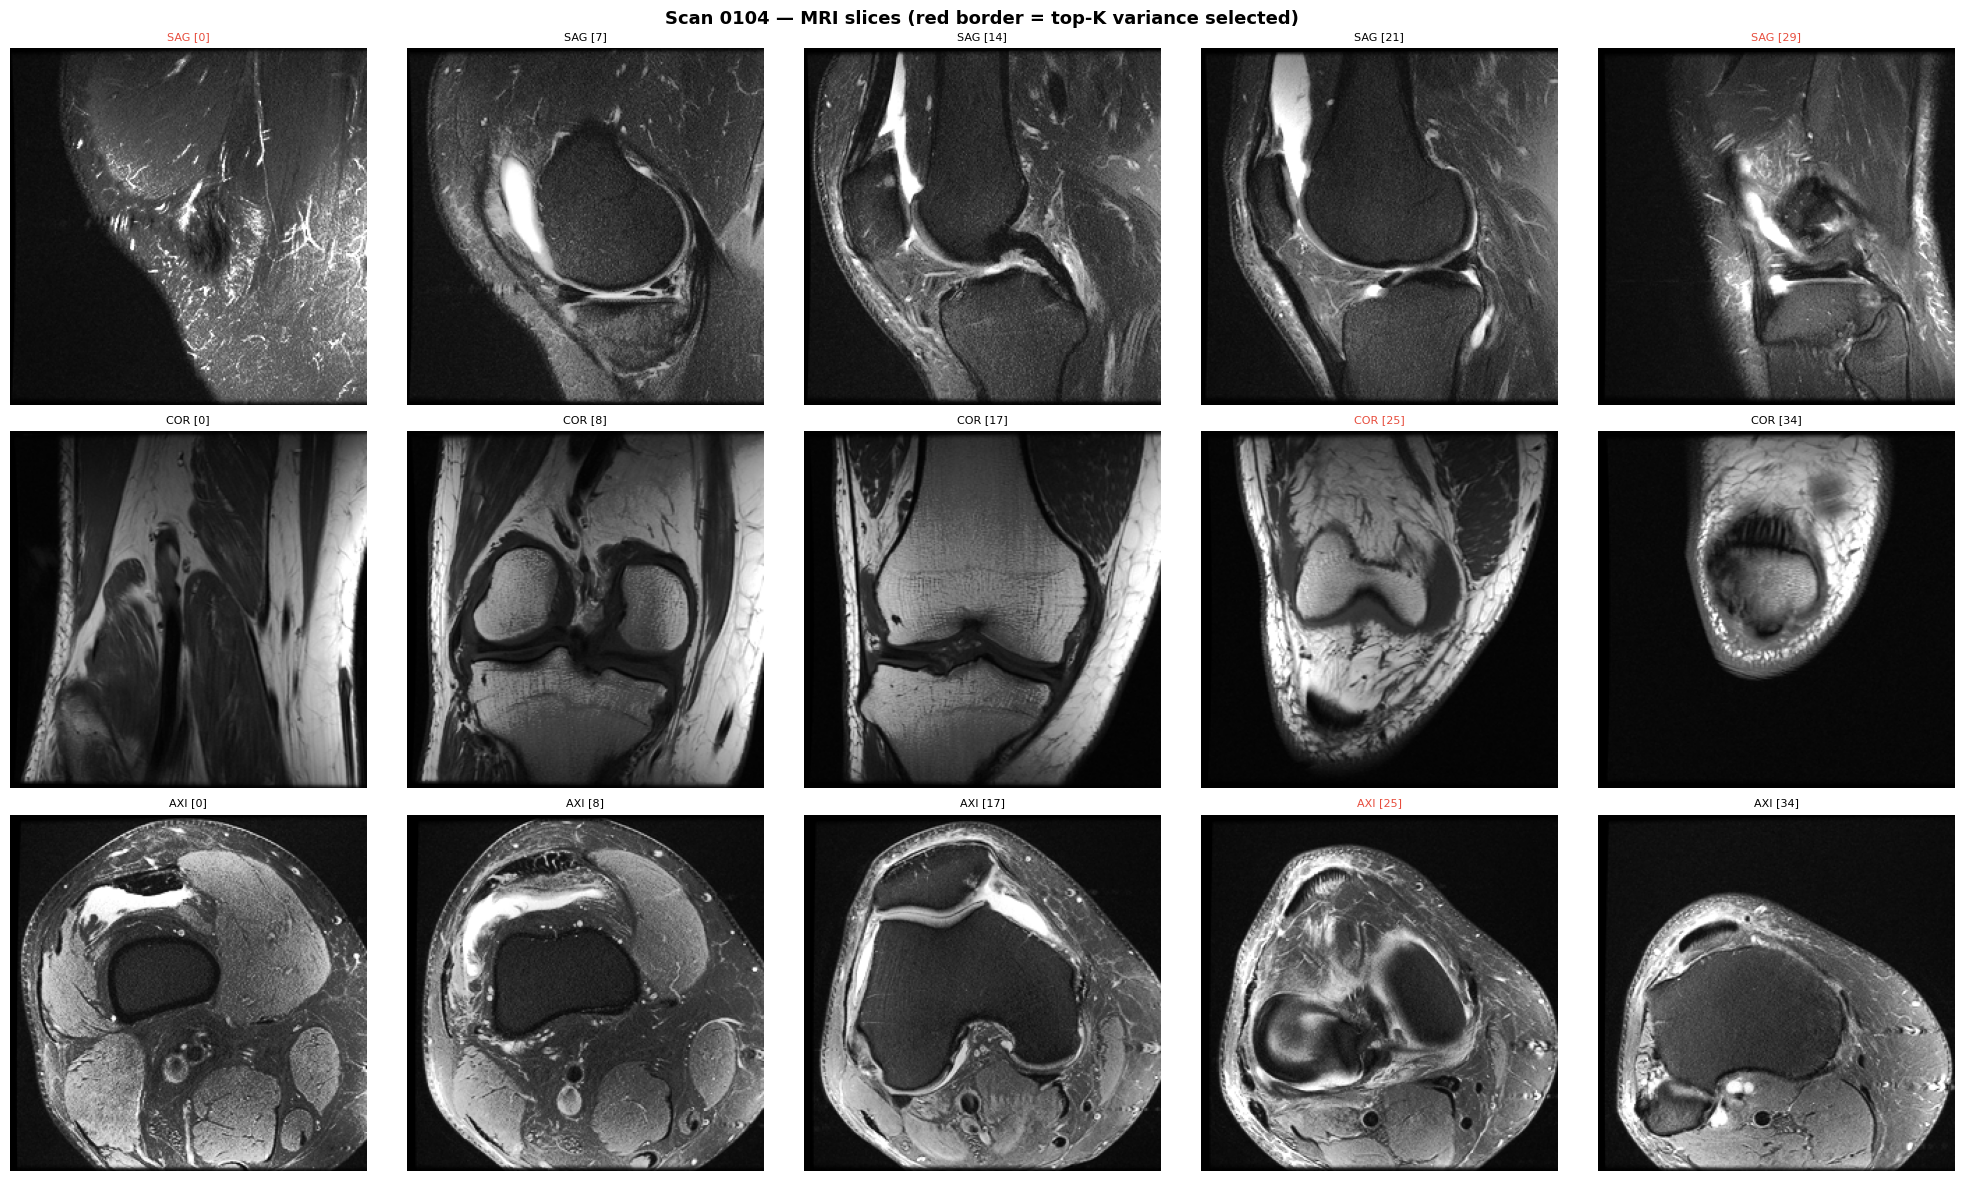

In [7]:
# Plot 2: Sample MRI slices
sample_id = train_df["id"].iloc[0]
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle(f"Scan {sample_id} — MRI slices (red border = top-K variance selected)",
             fontsize=13, fontweight="bold")

for row_i, plane in enumerate(["sagittal","coronal","axial"]):
    vol  = np.load(str(CFG.ROOT/"train"/plane/f"{sample_id}.npy"))
    D    = vol.shape[0]
    var  = np.var(vol.reshape(D,-1), axis=1)
    topk = np.sort(np.argsort(var)[-CFG.TOP_K_SLICES:])
    for col_i, idx in enumerate(np.linspace(0, D-1, 5, dtype=int)):
        ax = axes[row_i, col_i]
        ax.imshow(vol[idx], cmap="gray"); ax.axis("off")
        in_topk = any(abs(int(idx)-int(t))<=1 for t in topk)
        c = "#E74C3C" if in_topk else "white"
        for sp in ax.spines.values(): sp.set_edgecolor(c); sp.set_linewidth(3)
        ax.set_title(f"{plane[:3].upper()} [{idx}]",
                     fontsize=8, color="#E74C3C" if in_topk else "black")

plt.tight_layout()
plt.savefig(CFG.OUT_DIR/"eda_sample_slices.png", dpi=150, bbox_inches="tight")
plt.show()
